In [23]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

# ------------------
# Parameters
# ------------------
N_arr = np.arange(2, 14, 2)
nmax  = 20
ω = ω0 = g = 1.0
tlist = np.arange(0.01, 2*np.pi, 0.1)

# ------------------
# Tavis–Cummings Hamiltonian
# ------------------
def tavis_cummings(N, nmax, ω, ω0, g):

    a  = qt.destroy(nmax)
    Ic = qt.qeye(nmax)

    sp, sm, sz = qt.sigmap(), qt.sigmam(), qt.sigmaz()

    def embed(op, i):
        ops = [qt.qeye(2)]*N
        ops[i] = op
        return qt.tensor(ops)

    Sp = sum(embed(sp, i) for i in range(N))
    Sm = Sp.dag()
    Sz = 0.5 * sum(embed(sz, i) for i in range(N))

    IB = qt.tensor([qt.qeye(2)]*N)
    HB = ω0 * Sz
    
    
    H = (ω * qt.tensor(a.dag()*a, IB) + ω0 * qt.tensor(Ic, HB) + (g / np.sqrt(N)) * (qt.tensor(a, Sp) + qt.tensor(a.dag(), Sm)))

    return H, HB

# ------------------
# Initial state
# ------------------

def initial_battery_ground(N):
    return qt.tensor([qt.basis(2, 0) for _ in range(N)])
    
def initial_state(N, nmax, state):

    if state == "coherent":
        psiA = qt.coherent(nmax, np.sqrt(N))
    elif state == "fock":
        psiA = qt.basis(nmax, N)
    psiB = initial_battery_ground(N)  
    # psiB = qt.tensor([qt.basis(2, 1) for _ in range(N)])
    return qt.tensor(psiA, psiB)

def ergotropy_analytic(ρ, ω, N):
    # largest eigenvalue of rho_B
    eta_max = np.max(ρ.eigenenergies())

    # delta(N) = 1 - eta_0^↓
    delta = 1.0 - eta_max

    # ergotropy: 𝓔_B = N ω_B / 2 − ω_B δ(N)
    return ω0 * (N/2 - delta)


def variance_analytic(ρ, ω, N):
    # largest eigenvalue of rho_B
    eta_max = np.max(ρ.eigenenergies())

    # delta(N) = 1 - eta_0^↓
    delta = 1.0 - eta_max

    # variance: 
    return (2/N) * np.sqrt(eta_max * delta)

N= 2, τ=0.010, E_B=1.000
N= 4, τ=0.010, E_B=2.000
N= 6, τ=0.010, E_B=3.000
N= 8, τ=0.010, E_B=4.000
N=10, τ=0.010, E_B=5.000
N=12, τ=0.010, E_B=6.000


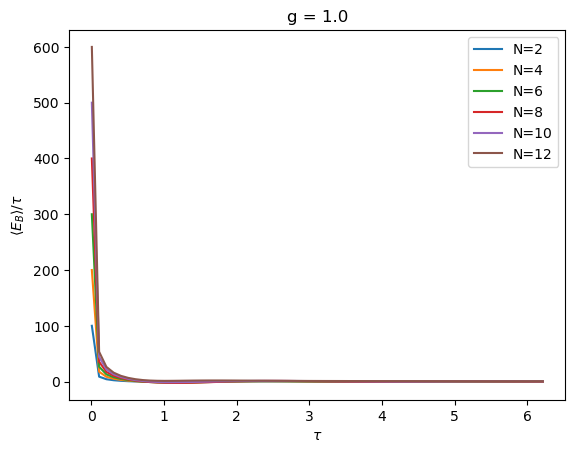

In [24]:

# ------------------
# Main loop
# ------------------
τ_list = []

for N in N_arr:

    H, HB = tavis_cummings(N, nmax, ω, ω0, g)
    HB_full = qt.tensor(qt.qeye(nmax), HB)

    ψ0 = initial_state(N, nmax, "coherent")

    result = qt.sesolve(H, ψ0, tlist, e_ops=HB_full)
    Eb = np.array(result.expect[0])

    power = Eb / tlist
    idx = np.argmax(power)

    τ_list.append(tlist[idx])

    print(f"N={N:2d}, τ={tlist[idx]:.3f}, E_B={Eb[idx]:.3f}")

    plt.plot(tlist, power, label=f"N={N}")

plt.xlabel(r"$\tau$")
plt.ylabel(r"$\langle E_B\rangle/\tau$")
plt.legend()
plt.title(f"g = {g}")
plt.show()

N= 2, τ=0.010, Ergotropy=0.999950, ρb_λ_max=0.999950
N= 4, τ=0.010, Ergotropy=1.999975, ρb_λ_max=0.999975
N= 6, τ=0.010, Ergotropy=2.999983, ρb_λ_max=0.999983
N= 8, τ=0.010, Ergotropy=3.999988, ρb_λ_max=0.999988
N=10, τ=0.010, Ergotropy=4.999990, ρb_λ_max=0.999990
N=12, τ=0.010, Ergotropy=5.999990, ρb_λ_max=0.999990


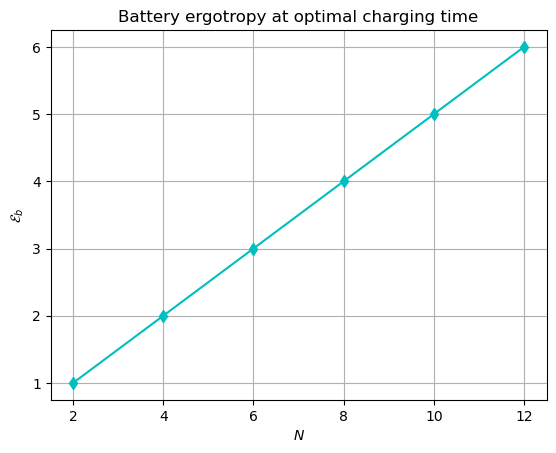

In [25]:
erg_list = []
var_list = []

for i, N in enumerate(N_arr):

    τ = τ_list[i]

    # Rebuild Hamiltonian
    H, HB = tavis_cummings(N, nmax, ω, ω0, g)

    # Initial state
    ψ0 = initial_state(N, nmax, "coherent")

    # Evolve until τ
    result = qt.sesolve(H, ψ0, [0, τ])

    # Full density matrix at τ
    ρ_full = result.states[-1].proj()

    # Partial trace over cavity
    ρb = ρ_full.ptrace(1)

    ρb_λ_max = np.max(ρb.eigenenergies())
    # Ergotropy 
    erg = ergotropy_analytic(ρb, ω0, N)
    var = variance_analytic(ρb, ω0, N)
    
    print(f"N={N:2d}, τ={τ:.3f}, Ergotropy={erg:.6f}, ρb_λ_max={ρb_λ_max:.6f}")

    erg_list.append(erg)
    var_list.append(var)


# ------------------
# Plot
# ------------------
plt.figure()
plt.plot(N_arr[:len(erg_list)], erg_list, 'd-', color='c')
plt.xlabel(r"$N$")
plt.ylabel(r"$\mathcal{E}_b$")
plt.title("Battery ergotropy at optimal charging time")
plt.grid()
plt.show()

N= 2, τ=0.010, Erg / <EB>=1.000290
N= 4, τ=0.010, Erg / <EB>=1.000245
N= 6, τ=0.010, Erg / <EB>=1.000230
N= 8, τ=0.010, Erg / <EB>=1.000222
N=10, τ=0.010, Erg / <EB>=1.000215
N=12, τ=0.010, Erg / <EB>=1.000201


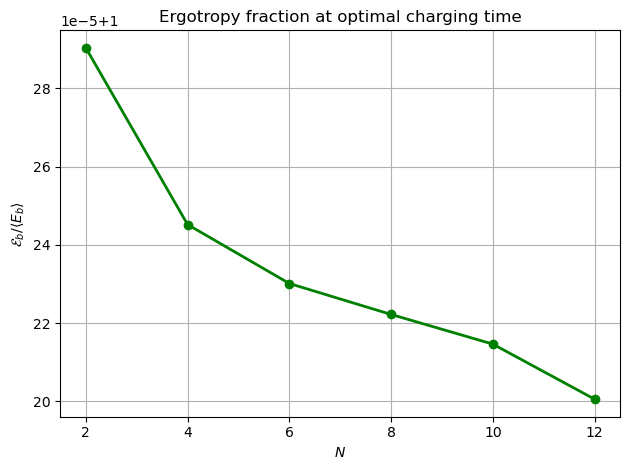

In [26]:
erg_list = []
Eb_list  = []

for i, N in enumerate(N_arr):

    H, HB = tavis_cummings(N, nmax, ω, ω0, g)
    psi0  = initial_state(N, nmax, "coherent")

    result = qt.sesolve(H, psi0, [0, τ_list[i]])
    rho = result.states[-1]

    # FIX: trace out cavity only
    rho_b = rho.ptrace(list(range(1, len(rho.dims[0]))))

    Eb  = qt.expect(HB, rho_b)
    erg = ergotropy_analytic(ρb, ω0, N)
    
    Eb_list.append(Eb)
    erg_list.append(erg)

Eb_arr  = np.array(Eb_list)
erg_arr = np.array(erg_list)

ratio = erg_arr / (Eb_arr + 1e-20)

for i, N in enumerate(N_arr):
    print(f"N={N:2d}, τ={τ_list[i]:.3f}, Erg / <EB>={ratio[i]:.6f}")

plt.figure()
plt.plot(N_arr, ratio, 'o-', color='g', linewidth=2)
plt.xlabel(r"$N$")
plt.ylabel(r"$\mathcal{E}_b / \langle E_b \rangle$")
plt.title("Ergotropy fraction at optimal charging time")
plt.grid(True)
plt.tight_layout()
plt.show()

N= 2, τ=0.010, Relative Fluctuation =0.084088
N= 4, τ=0.010, Relative Fluctuation =0.025000
N= 6, τ=0.010, Relative Fluctuation =0.012296
N= 8, τ=0.010, Relative Fluctuation =0.007421
N=10, τ=0.010, Relative Fluctuation =0.005003
N=12, τ=0.010, Relative Fluctuation =0.003798


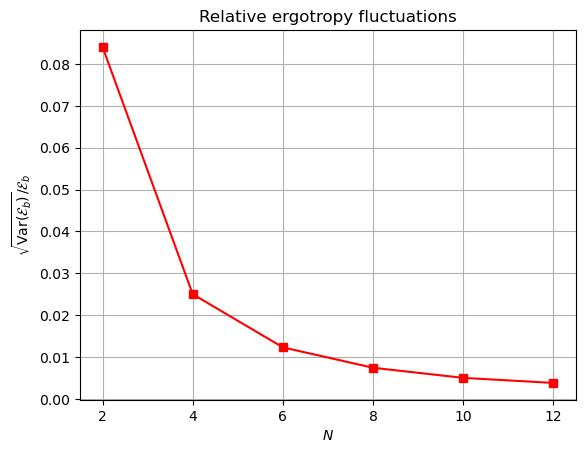

In [27]:
erg_arr = np.array(erg_list)
var_arr = np.array(var_list)

####################################################
# Plot fluctuations as function of g for different N 
####################################################

rel_fluct = np.sqrt(np.array(var_list)) / np.array(erg_list)

for idx, N in enumerate(N_arr):
    print(f"N={N:2d}, τ={τ_list[idx]:.3f}, Relative Fluctuation ={rel_fluct[idx]:.6f}")

plt.figure()
plt.plot(N_arr, rel_fluct, 's-', color='r')
plt.xlabel(r"$N$")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$")
plt.title("Relative ergotropy fluctuations")
plt.grid()
plt.show()